In [27]:
import json
import os
import re
from collections import defaultdict
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import seaborn as sns
import torch
from matplotlib import font_manager, rcParams
from sklearn.metrics import f1_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [28]:
output_dir = "/home/slim/dpo-rhlf-paraphrase-types/out/plots"
os.chdir("/home/slim/dpo-rhlf-paraphrase-types")

with open('/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-6-at-2024-11-11-11-01-407552a7.json', 'r') as f:
    annotations_data = json.load(f)
with open('/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/generated_paraphrases_Llama-3.1-8B.json', 'r') as f:
    evaluations_data = json.load(f)

TOP_10_PARAPHRASE_TYPES = [
    "addition/deletion",
    "change of order",
    "derivational changes",
    "inflectional changes",
    "punctuation changes",
    "same polarity substitution (contextual)",
    "semantic based",
    "spelling changes",
    "subordination and nesting changes",
    "synthetic/analytic substitution",
]

# Create a mapping from original types to their formatted names
PARAPHRASE_TYPE_MAPPING = {
    "additiondeletion": "Addition/Deletion",
    "addition/deletion": "Addition/Deletion",
    "AdditionDeletion": "Addition/Deletion",
    "change of order": "Change of order",
    "derivational changes": "Derivational Changes",
    "inflectional changes": "Inflectional Changes",
    "punctuation changes": "Punctuation Changes",
    "same polarity substitution (contextual)": "Same Polarity Substitution (contextual)",
    "semantic based": "Semantic Based",
    "spelling changes": "Spelling Changes",
    "subordination and nesting changes": "Subordination and Nesting Changes",
    "syntheticanalytic substitution": "Synthetic/Analytic Substitution",
    "synthetic/analytic substitution": "Synthetic/Analytic Substitution",
    "Syntheticanalytic substitution": "Synthetic/Analytic Substitution",
    "Synthetic/analytic substitution": "Synthetic/Analytic Substitution",
}


def add_line_breaks(text, n=2):
    # Add a custom line break for "synthetic/analytic substitution"
    if text == "Synthetic/Analytic Substitution":
        return "Synthetic/Analytic\nsubstitution"
    if text == "same polarity substitution (contextual)":
        return "Same polarity\nsubstitution (cont.)"

    # Otherwise, split the text into words and add line breaks every `n` words
    words = text.split(" ")
    lines = [" ".join(words[i : i + n]) for i in range(0, len(words), n)]
    return "\n".join(lines)


textwidth1 = 5.47  # onecolumn
aspect_ratio = (5**0.5 - 1) / 2  # golden ratio
width1 = textwidth1
height1 = width1 * aspect_ratio
textwidthcm = 15.99773  # onecolumn
textwidthcm = 7.82315  # twocolumn
textheightcm = textwidthcm / aspect_ratio

In [29]:
libertine_path = "/usr/share/fonts/opentype/linux-libertine/LinLibertine_R.otf"

font_dirs = [
    "/usr/share/fonts/opentype/linux-libertine"
]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)


# Function to convert CMYK to RGB
def cmyk_to_rgb(c, m, y, k):
    r = 1 - min(1, c * (1 - k) + k)
    g = 1 - min(1, m * (1 - k) + k)
    b = 1 - min(1, y * (1 - k) + k)
    return (r, g, b)


# Define colors using the CMYK values
ACMBlue = cmyk_to_rgb(1, 0.1, 0, 0.1)
ACMYellow = cmyk_to_rgb(0, 0.16, 1, 0)
ACMOrange = cmyk_to_rgb(0, 0.42, 1, 0.01)
ACMRed = cmyk_to_rgb(0, 0.90, 0.86, 0)
ACMLightBlue = cmyk_to_rgb(0.49, 0.01, 0, 0)
ACMGreen = cmyk_to_rgb(0.20, 0, 1, 0.19)
ACMPurple = cmyk_to_rgb(0.55, 1, 0, 0.15)
ACMDarkBlue = cmyk_to_rgb(1, 0.58, 0, 0.21)

acm_palette = [
    ACMBlue,
    ACMYellow,
    ACMOrange,
    ACMRed,
    ACMLightBlue,
    ACMGreen,
    ACMPurple,
    ACMDarkBlue,
]

# Results
## Effectiveness of DPO and RHLF in Paraphrase Generation
### Llama-2

In [30]:
# Load the JSON data
with open(
    "/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json",
    "r",
) as file:
    data = json.load(file)

# Dictionary to store counts for each model
model_results = defaultdict(lambda: {"yes": 0, "total": 0})

# Iterate through each entry in the JSON data
for entry in data:
    kind = entry["data"]["Kind"]
    # Check the "APT" choice value in the annotations
    for annotation in entry["annotations"]:
        for result in annotation["result"]:
            if result["from_name"] == "APT":
                choice = result["value"]["choices"][0]
                model_results[kind]["total"] += 1
                if choice == "Yes":
                    model_results[kind]["yes"] += 1

# Calculate accuracy for each model
apt_percentages = {
    model: (counts["yes"] / counts["total"]) * 100
    for model, counts in model_results.items()
}


print(apt_percentages)

{'base_model': 12.376237623762377, 'etpc_model': 11.76470588235294, 'dpo_model': 35.26315789473684}


In [31]:
# Dictionary to store counts for each (model, APT) pair
results = defaultdict(lambda: {"yes": 0, "total": 0})

# Iterate through each entry in the JSON data
for entry in data:
    # Ensure entry is a dictionary before processing
    if isinstance(entry, dict):
        kind = entry.get("data", {}).get("Kind")
        apt_value = entry.get("data", {}).get("APT")

        # Proceed only if both kind and apt_value are found
        if kind and apt_value:
            annotations = entry.get("annotations", [])

            # Check if there are annotations
            if annotations:
                for annotation in annotations:
                    results_found = annotation.get("result", [])

                    # Iterate through each result within the annotation
                    for result in results_found:
                        from_name = result.get("from_name")

                        # Focus on results where from_name is "APT"
                        if from_name == "APT":
                            choice = result.get("value", {}).get("choices", [None])[0]

                            # Check if the choice is valid
                            if choice:
                                results[(kind, apt_value)]["total"] += 1
                                if choice == "Yes":
                                    results[(kind, apt_value)]["yes"] += 1

# Calculate accuracy for each (model, APT) pair
apt_percentages = {
    (model, apt): (counts["yes"] / counts["total"]) * 100
    for (model, apt), counts in results.items()
    if counts["total"] > 0  # Avoid division by zero
}

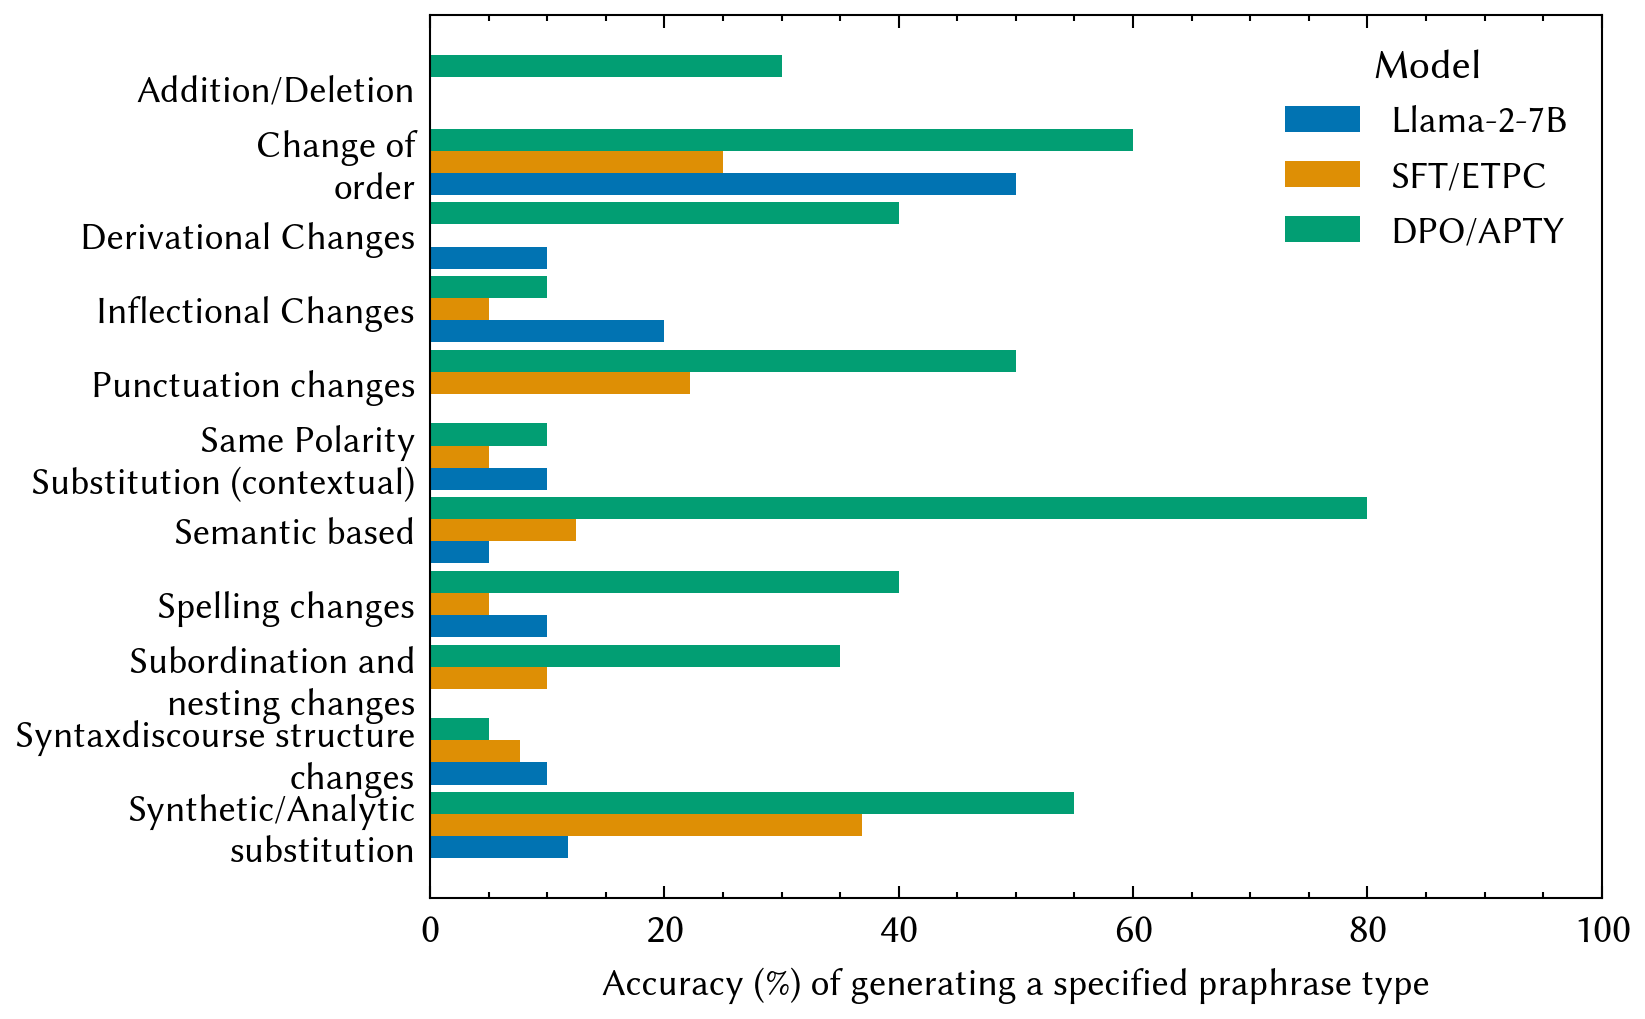

In [32]:
# Create a set of unique APT values and models in the specified order
apt_values = set(apt for _, apt in apt_percentages.keys())
models = ["base_model", "etpc_model", "dpo_model"]  # Ordered list of models
model_labels = {
    "base_model": "Llama-2-7B",
    "etpc_model": "SFT/ETPC",
    "dpo_model": "DPO/APTY",
}


# Create a dictionary to hold accuracy values for each model across APTs
model_accuracies = {
    model: [apt_percentages.get((model, apt), 0) for apt in apt_values]
    for model in models
}

mapped_apt_values = {PARAPHRASE_TYPE_MAPPING.get(apt, apt) for apt in apt_values}
sorted_apt_values = sorted(mapped_apt_values, reverse=True)
sorted_apt_values = [add_line_breaks(apt, n=2) for apt in sorted_apt_values]

# Create data for plotting
y = np.arange(len(sorted_apt_values))  # the label locations for the y-axis
width = 0.3  # the width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
plt.style.use(["science", "no-latex"])
sns.set_palette("colorblind")
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]

# Plot each model's accuracy as a separate set of horizontal bars
for i, model in enumerate(models):
    plt.barh(
        y + i * width, model_accuracies[model], height=width, label=model_labels[model]
    )

# Add labels and title
plt.xlabel("Accuracy (%) of generating a specified praphrase type", fontsize=9)
ax.set_yticks(y + width * (len(models) - 1) / 2, labels=sorted_apt_values, fontsize=9)
plt.xlim(0, 100)
plt.legend(title="Model", fontsize=9)

ax.tick_params(axis="y", which="both", left=False, right=False)

output_path = os.path.join(output_dir, "llama2_type_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Display the plot
plt.show()

### Llama-3.1

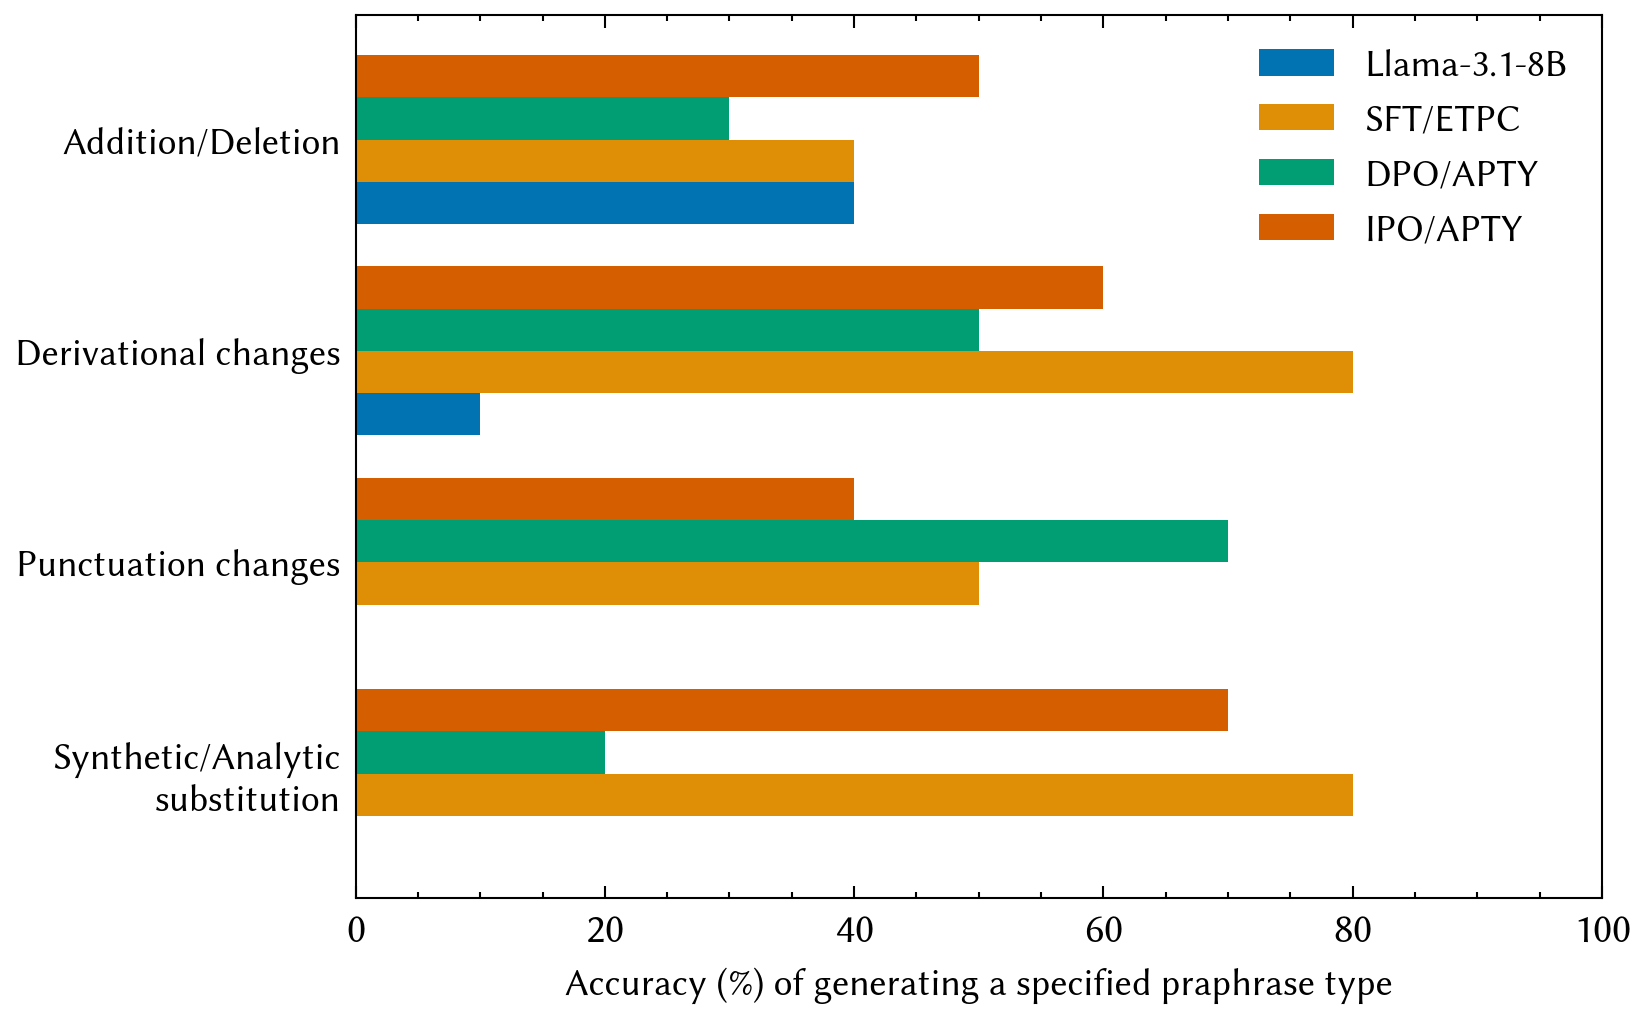

In [33]:
def create_accuracy_plot(data):
    # Initialize result dictionary
    results = {}
    
    # Process data to calculate accuracies
    for item in data:
        apt_type = item['data'].get('APT')
        if not apt_type:
            continue
        
        mapped_apt = PARAPHRASE_TYPE_MAPPING.get(apt_type, apt_type)
        if mapped_apt not in results:
            results[mapped_apt] = {
                'Llama-3.1-8B': {'good': 0, 'total': 0},
                'SFT/ETPC': {'good': 0, 'total': 0},
                'DPO/APTY': {'good': 0, 'total': 0},
                'IPO/APTY': {'good': 0, 'total': 0}
            }
            
        for annotation in item['annotations']:
            for result in annotation['result']:
                if result['from_name'] == 'annot':
                    ranker = result['value'].get('ranker', {})
                    model_map = {
                        '0': 'Llama-3.1-8B',
                        '1': 'SFT/ETPC',
                        '2': 'DPO/APTY',
                        '3': 'IPO/APTY'
                    }
                    
                    # Count good rankings (a+b) and total annotations
                    for model_id in model_map:
                        model_name = model_map[model_id]
                        good_count = len([x for x in ranker.get('a', []) + ranker.get('b', []) if x == model_id])
                        total_count = sum(1 for lst in ranker.values() if model_id in lst)
                        results[mapped_apt][model_name]['good'] += good_count
                        results[mapped_apt][model_name]['total'] += total_count

    # Convert to DataFrame
    df_data = []
    for apt, models in results.items():
        row = {'APT': add_line_breaks(apt, n=2)}  # Apply line breaks
        for model, counts in models.items():
            accuracy = counts['good']/counts['total'] if counts['total'] > 0 else 0
            row[model] = accuracy*100
        df_data.append(row)
    
    df = pd.DataFrame(df_data)
    
    # Sort the DataFrame by the 'APT' column alphabetically
    df = df.sort_values(by='APT', ascending=False)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
    plt.style.use(["science", "no-latex"])
    sns.set_palette("colorblind")
    rcParams["font.family"] = "sans-serif"
    rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]
    
    models = ['Llama-3.1-8B', 'SFT/ETPC', 'DPO/APTY', 'IPO/APTY']
    x = np.arange(len(df['APT']))
    width = 0.2
    
    for i, model in enumerate(models):
        ax.barh(x + i*width, df[model], width, label=model)
    
    ax.set_yticks(x + width*1.5)
    ax.set_yticklabels(df['APT'], fontsize=9)
    ax.tick_params(axis="y", which="both", left=False, right=False)
    ax.set_xlabel("Accuracy (%) of generating a specified praphrase type", fontsize=9)
    plt.xlim(0, 100)
    ax.legend(fontsize=9)
    
    return plt

# Usage:
    
plot = create_accuracy_plot(annotations_data)

output_path = os.path.join(output_dir, "llama3_type_ranking.pdf")
plt.savefig(output_path, dpi=300)

plot.show()

## Incorporating Human-Ranked Data for Improved Paraphrase Generation

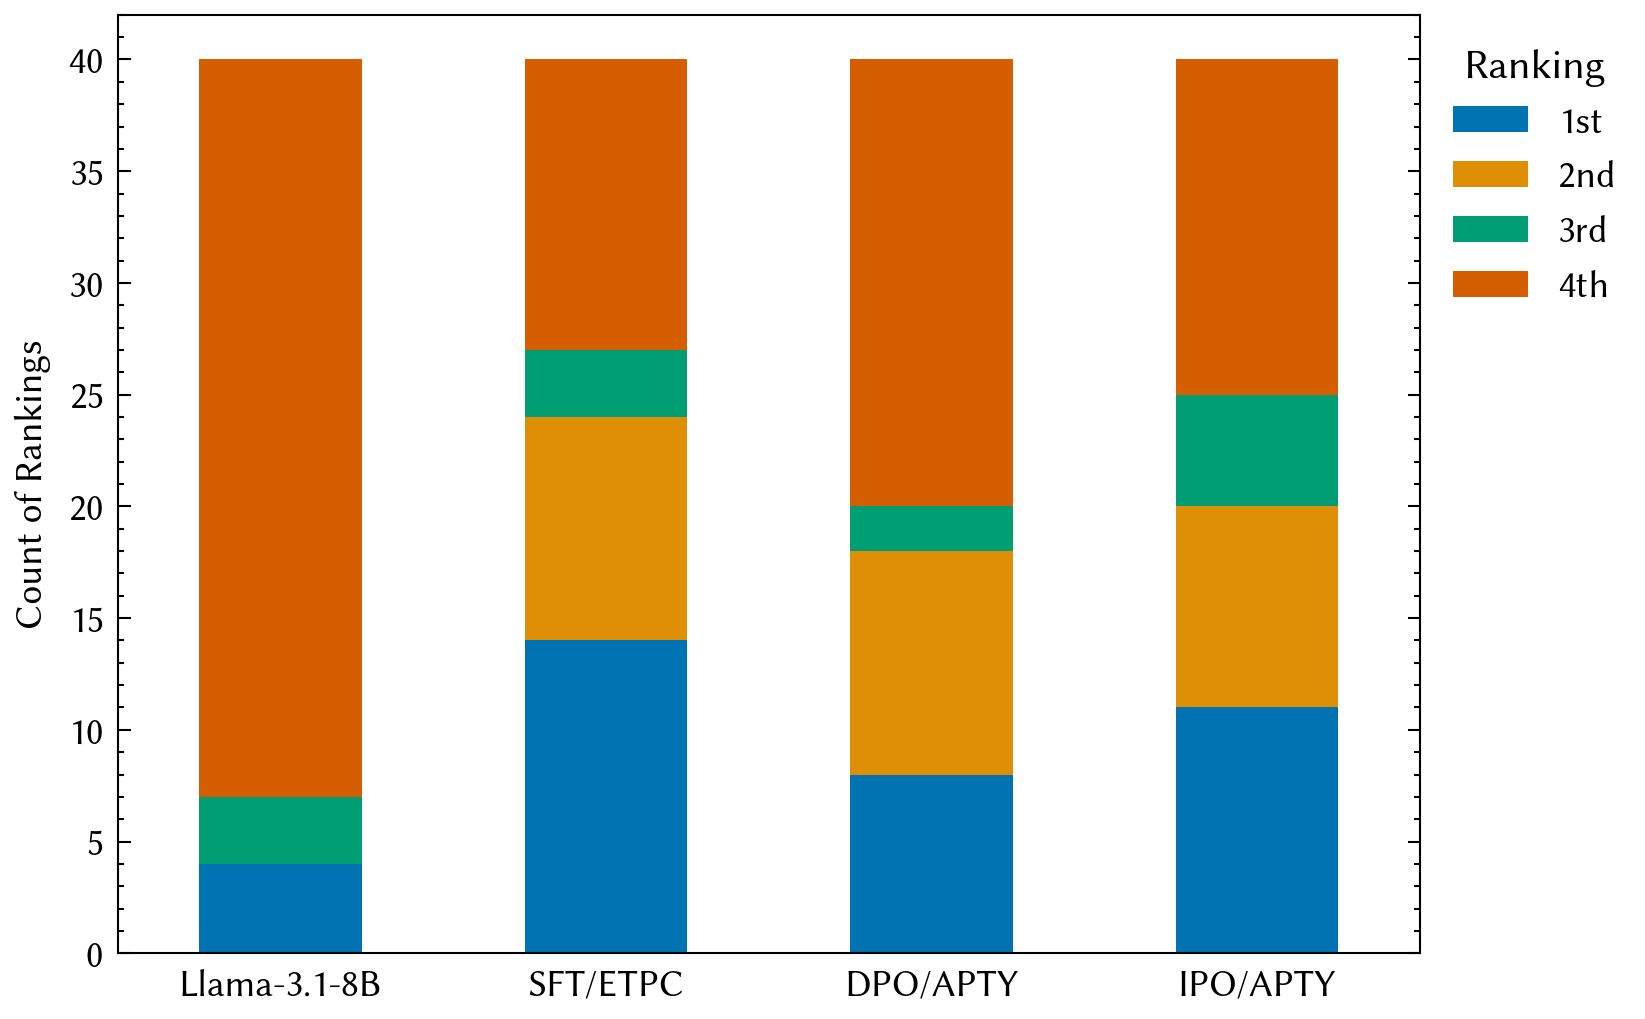

In [34]:
def analyze_rankings(data):
    # Initialize counters
    rank_counts = {
        'Llama-3.1-8B': {1: 0, 2: 0, 3: 0, 4: 0},
        'SFT/ETPC': {1: 0, 2: 0, 3: 0, 4: 0}, 
        'DPO/APTY': {1: 0, 2: 0, 3: 0, 4: 0},
        'IPO/APTY': {1: 0, 2: 0, 3: 0, 4: 0}
    }
    
    # Model ID mapping
    model_map = {
        '0': 'Llama-3.1-8B',
        '1': 'SFT/ETPC',
        '2': 'DPO/APTY', 
        '3': 'IPO/APTY'
    }

    # Count rankings
    for item in data:
        for annotation in item['annotations']:
            for result in annotation['result']:
                if result['from_name'] == 'rank':
                    ranker = result['value']['ranker']
                    for rank, model_ids in ranker.items():
                        if rank != '_':  # Skip empty rankings
                            rank_num = int(rank)
                            for model_id in model_ids:
                                if model_id in model_map:
                                    rank_counts[model_map[model_id]][rank_num] += 1

    # Convert to DataFrame
    df = pd.DataFrame(rank_counts).transpose()
    
    return df

# Create plot
def create_ranking_plot(df):
    fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
    plt.style.use(["science", "no-latex"])
    sns.set_palette("colorblind")
    rcParams["font.family"] = "sans-serif"
    rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]

    df.plot(kind='bar', stacked=True, ax=ax)
    
    ax.set_ylabel("Count of Rankings", fontsize=9)
    ax.tick_params(axis="x", which="both", top=False, bottom=False, labelsize=9, rotation=0)
    ax.tick_params(axis="y", labelsize=9)
    
    ax.legend(title="Ranking", 
             labels=["1st", "2nd", "3rd", "4th"],
             bbox_to_anchor=(1.0, 1),
             loc='upper left',
             fontsize=9)
    
    return plt

# Load and process data
df = analyze_rankings(annotations_data)
plot = create_ranking_plot(df)

output_path = os.path.join(output_dir, "apt_ranking.pdf")
plt.savefig(output_path, dpi=300)

plot.show()

## Broader NLP Task Improvements with Human-Ranked Data

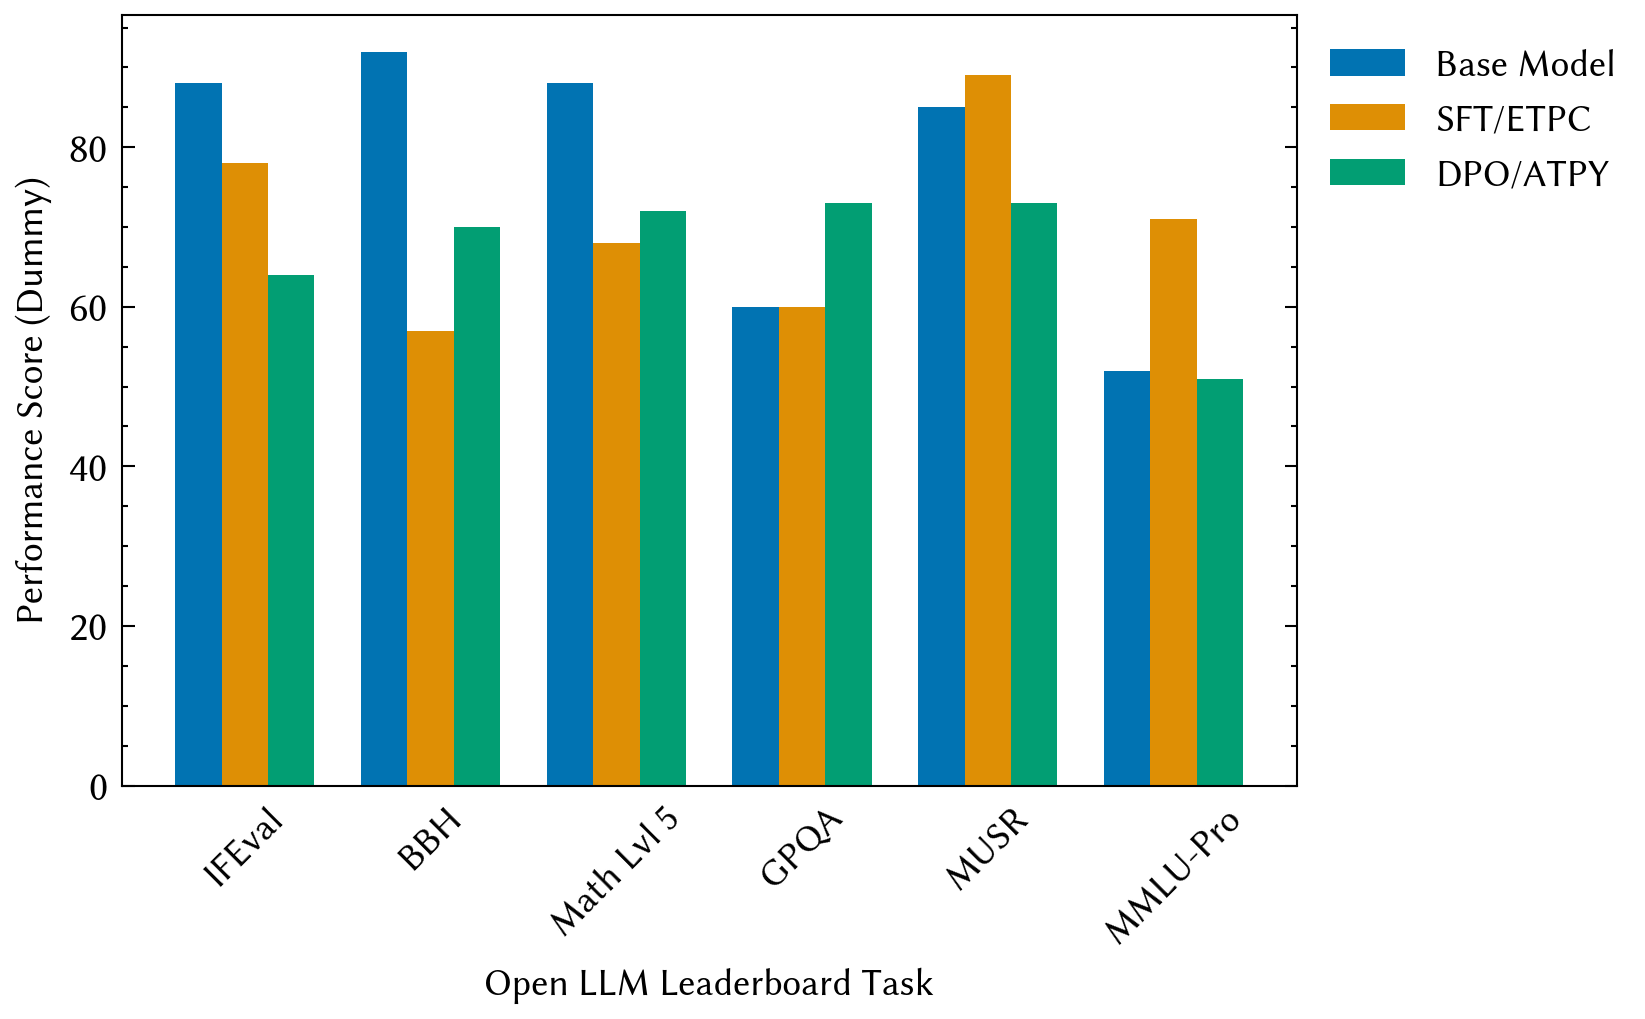

In [35]:
# Define tasks and models
tasks = ["IFEval", "BBH", "Math Lvl 5", "GPQA", "MUSR", "MMLU-Pro"]
models = ["Base Model", "SFT/ETPC", "DPO/ATPY"]

# Create dummy scores for each task and model
np.random.seed(42)
scores = np.random.randint(50, 100, size=(len(tasks), len(models)))

# Create a grouped bar chart
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
plt.style.use(["science", "no-latex"])
sns.set_palette("colorblind")
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]

bar_width = 0.25
index = np.arange(len(tasks))

# Plot bars for each model
for i, model in enumerate(models):
    ax.bar(index + i * bar_width, scores[:, i], bar_width, label=model)

# Set labels, title, and ticks
ax.set_xlabel("Open LLM Leaderboard Task", fontsize=9)
ax.set_xticks(index + bar_width)
ax.set_xticklabels(tasks, fontsize=9)
ax.tick_params(axis="x", which="both", bottom=False, top=False, labelsize=9)
plt.xticks(rotation=45)

ax.set_ylabel("Performance Score (Dummy)", fontsize=9)

# Add legend
ax.legend(
    fontsize=9,
    bbox_to_anchor=(1, 1),
    loc="upper left",
)

output_path = os.path.join(output_dir, "llmboard.pdf")
plt.savefig(output_path, dpi=300)

plt.show()

## Correlation Between Automatic Metrics and Human Judgment

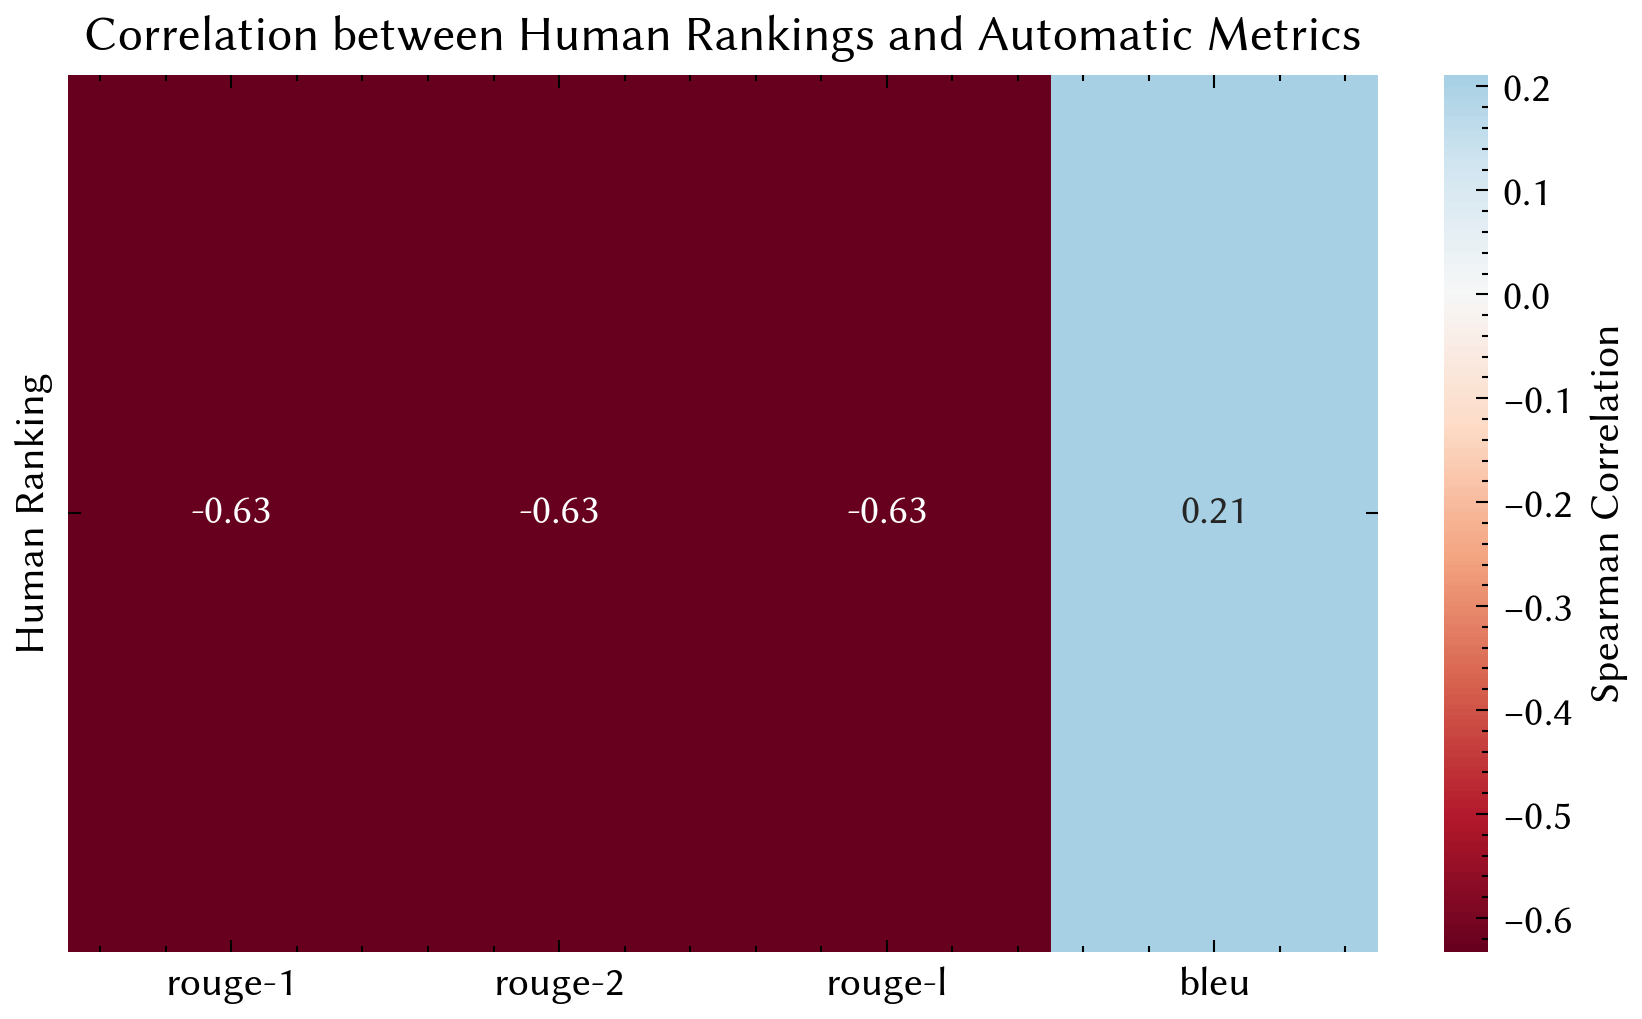

In [36]:


def analyze_correlations():
    # Extract rankings and create dataframe
    rankings_data = []
    for item in annotations_data:  # project-6 json
        item_id = item['data']['id']
        for annotation in item['annotations']:
            for result in annotation['result']:
                if result['from_name'] == 'rank':
                    ranker = result['value']['ranker']
                    # Convert rankings (1=best, 4=worst)
                    for rank, model_ids in ranker.items():
                        if rank != '_':
                            for model_id in model_ids:
                                rankings_data.append({
                                    'id': item_id,
                                    'model': model_id,
                                    'rank': int(rank)
                                })
                            
    rankings_df = pd.DataFrame(rankings_data)

    # Extract scores from evaluations
    scores_data = []
    for item in evaluations_data:  # generated_paraphrases json
        item_id = item['id']
        for model_output in item['List']:
            if 'evaluation' in model_output:
                scores_data.append({
                    'id': item_id,
                    'model': str(model_output['id']),
                    'rouge-1': model_output['evaluation']['rouge-1'],
                    'rouge-2': model_output['evaluation']['rouge-2'],
                    'rouge-l': model_output['evaluation']['rouge-l'],
                    'bleu': model_output['evaluation']['bleu']
                })
    
    scores_df = pd.DataFrame(scores_data)
    
    # Merge rankings and scores
    combined_df = pd.merge(rankings_df, scores_df, on=['id', 'model'])

    # Calculate correlations
    metrics = ['rouge-1', 'rouge-2', 'rouge-l', 'bleu']
    corr_data = np.zeros((1, len(metrics)))
    
    # Spearman correlation between rank and each metric
    for i, metric in enumerate(metrics):
        corr = combined_df[metric].corr(combined_df['rank'], method='spearman')
        corr_data[0,i] = corr
        
    # Create correlation plot
    fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
    plt.style.use(["science", "no-latex"])
    sns.set_palette("colorblind")
    rcParams["font.family"] = "sans-serif"
    rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]
    
    sns.heatmap(
        corr_data, 
        xticklabels=metrics,
        yticklabels=['Human Ranking'],
        cmap='RdBu',
        center=0,
        annot=True,
        fmt='.2f',
        cbar_kws={'label': 'Spearman Correlation'}
    )
    
    plt.title("Correlation between Human Rankings and Automatic Metrics")
    
    return plt

# Create and save plot
plot = analyze_correlations()

output_path = os.path.join(output_dir, "correlation_matrix.pdf")
plt.savefig(output_path, dpi=300)

plot.show()


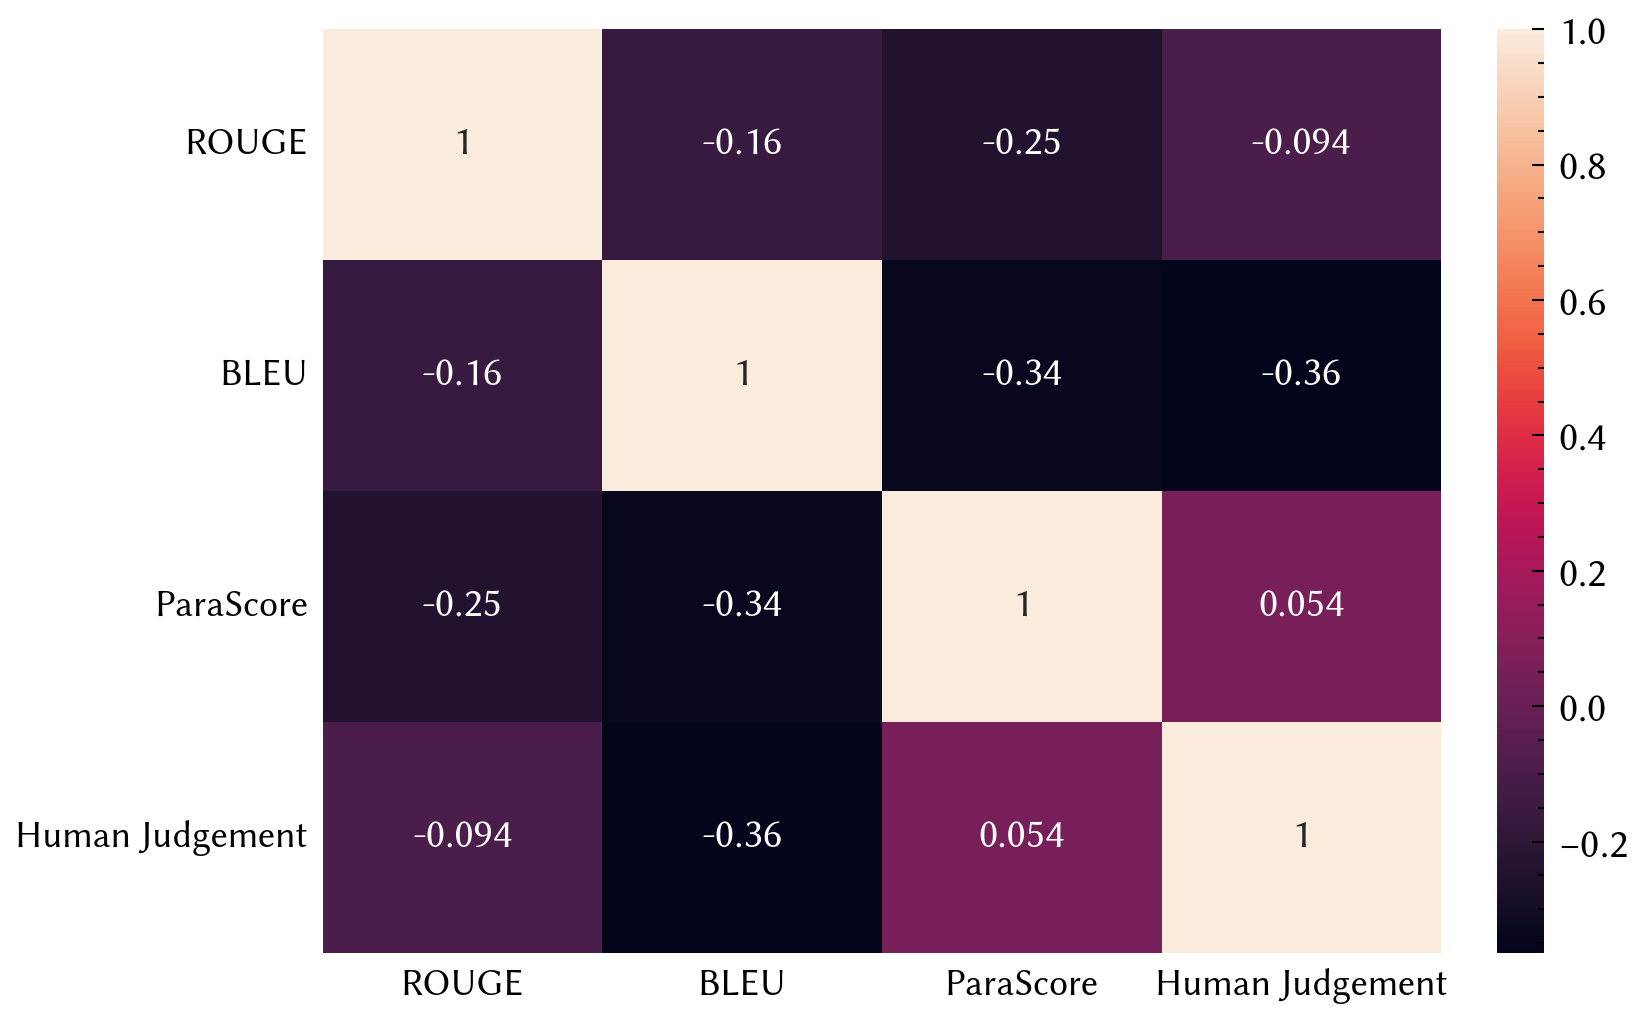

In [37]:
# Generate dummy scores for human rankings and automated metrics (ROUGE, BLEU, ParaScore)
rouge_scores = np.random.uniform(0.4, 0.9, size=10)  # ROUGE scores
bleu_scores = np.random.uniform(0.3, 0.8, size=10)  # BLEU scores
parascale_scores = np.random.uniform(0.5, 0.95, size=10)  # ParaScore
human_scores = np.random.uniform(0.5, 0.95, size=10)

# Create a DataFrame for correlation matrix
data = {
    "ROUGE": rouge_scores,
    "BLEU": bleu_scores,
    "ParaScore": parascale_scores,
    "Human Judgement": human_scores,
}
df = pd.DataFrame(data)

# Calculate the correlation matrix
corr_matrix = df.corr()

# Set figure size according to the provided description


# Create a heatmap for the correlation matrix
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
plt.style.use(["science", "no-latex"])
sns.set_palette("colorblind")
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]

sns.heatmap(corr_matrix, annot=True, ax=ax, annot_kws={"fontsize": 10})

# Remove only the tick marks (but keep the labels)
ax.tick_params(
    axis="x", which="both", bottom=False, top=False, labelsize=9
)  # Remove tick marks on the x-axis
ax.tick_params(
    axis="y", which="both", left=False, right=False, labelsize=9
)  # Remove tick marks on the y-axis

# Save the correlation matrix as a PDF
output_path = os.path.join(output_dir, "correlation_matrix.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

## New metric

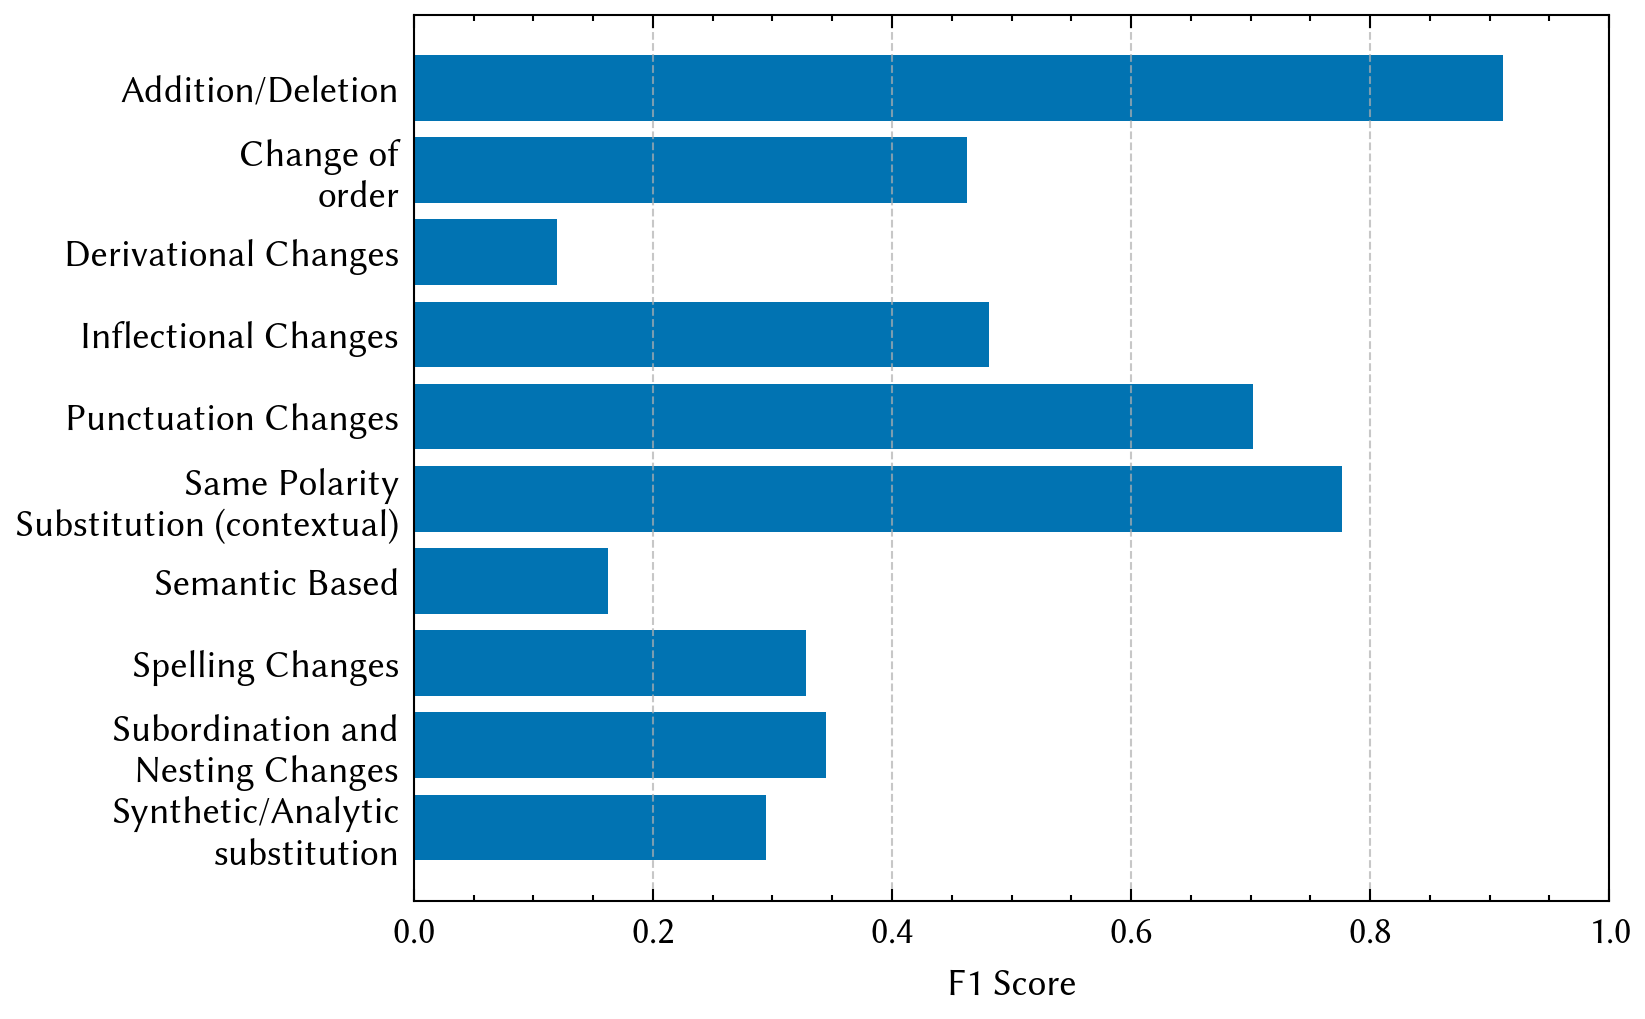

In [38]:
classification_data = pd.read_csv(
    "/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_ptd_results_hyperclass_20241024_161522.csv",
    skiprows=14,
)

classification_data["Paraphrase Type"] = (
    classification_data["Paraphrase Type"]
    .map(PARAPHRASE_TYPE_MAPPING)
    .fillna(classification_data["Paraphrase Type"])
)
classification_data["Paraphrase Type"] = classification_data["Paraphrase Type"].apply(
    lambda x: add_line_breaks(x, n=2)
)

# Extract F1 scores for each paraphrase type, excluding rows like 'micro avg', 'macro avg', etc.
paraphrase_f1_scores = classification_data[
    ~classification_data["Paraphrase Type"].str.contains("avg")
]
paraphrase_f1_scores = paraphrase_f1_scores.sort_values(
    by="Paraphrase Type", ascending=False
)

# Create the plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
plt.style.use(["science", "no-latex"])
sns.set_palette("colorblind")
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]

plt.barh(paraphrase_f1_scores["Paraphrase Type"], paraphrase_f1_scores["F1-score"])

plt.xlabel("F1 Score", fontsize=9)
ax.tick_params(axis="x", which="both", labelsize=9)  # Set x-axis labels to size
plt.xlim(0, 1)

plt.grid(axis="x", linestyle="--", alpha=0.7)

ax.tick_params(
    axis="y", which="both", left=False, right=False, labelsize=9
)  # Remove tick marks on the y-axis

output_path = os.path.join(output_dir, "new_type_score.pdf")
plt.savefig(output_path, dpi=300)

plt.show()

### Llama-2

In [39]:
TOP_10_PARAPHRASE_TYPES = [
    "additiondeletion",
    "change of order",
    "derivational changes",
    "inflectional changes",
    "punctuation changes",
    "same polarity substitution (contextual)",
    "semantic based",
    "spelling changes",
    "subordination and nesting changes",
    "syntheticanalytic substitution",
]


class ParaphraseTypeEvaluator:
    def __init__(self, model_name: str, top_k: int = 10):
        self.model_name = model_name
        self.top_k = top_k
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, local_files_only=True
        )
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name, clean_up_tokenization_spaces=True
        )
        self.model.eval()
        self.normalized_top_10_types = [
            ptype.strip().lower() for ptype in TOP_10_PARAPHRASE_TYPES
        ]

    def preprocess_apt(self, apt: str) -> List[str]:
        apt_types = apt.lower().split(", ")
        filtered_types = [
            ptype.strip()
            for ptype in apt_types
            if ptype.strip() in self.normalized_top_10_types
        ]
        return filtered_types

    def extract_paraphrase(self, paraphrase_list: List[str]) -> str:
        """Extracts the actual paraphrase text from the given list entry."""
        # Ensure the list has the expected structure and process the second element.
        if len(paraphrase_list) >= 2:
            paraphrase_entry = paraphrase_list[1]
            # Extract text after 'Generated Paraphrase:' and clean it up.
            match = re.search(
                r"Generated Paraphrase:(.*)", paraphrase_entry, re.IGNORECASE
            )
            if match:
                # Extract everything after 'Generated Paraphrase:'
                cleaned_paraphrase = match.group(1).strip()

                # If there are multiple numbered paraphrases, extract only the first one.
                # Look for "1." and "2."
                numbered_match = re.search(
                    r"1\.\s*(.*?)(?=\s*2\.)", cleaned_paraphrase, re.DOTALL
                )
                if numbered_match:
                    return numbered_match.group(1).strip()

                return cleaned_paraphrase
        return ""

    def predict_paraphrase_types(self, reference: str, paraphrase: str) -> List[str]:
        inputs = self.tokenizer(
            reference, paraphrase, truncation=True, max_length=256, return_tensors="pt"
        )
        with torch.no_grad():
            logits = self.model(**inputs).logits
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

        top_k_indices = np.argsort(probs)[-self.top_k :][::-1]  # Descending order
        predicted_types = [
            TOP_10_PARAPHRASE_TYPES[idx] for idx in top_k_indices if probs[idx] > 0.5
        ]
        return predicted_types

    def evaluate(self, json_file_path: str) -> pd.DataFrame:
        with open(json_file_path, "r", encoding="utf-8") as file:
            data = json.load(file)

        type_labels = {
            ptype: {"true_labels": [], "predicted_labels": []}
            for ptype in TOP_10_PARAPHRASE_TYPES
        }

        for entry in data:
            reference = entry["data"]["Original"]
            true_types = self.preprocess_apt(entry["data"]["APT"])
            paraphrase = self.extract_paraphrase(entry["data"]["Paraphrase"])

            predicted_types = self.predict_paraphrase_types(reference, paraphrase)

            # Store true and predicted labels for each paraphrase type
            for ptype in TOP_10_PARAPHRASE_TYPES:
                # True label: 1 if the human annotation is "Yes" and the ptype is in true_types
                ptype_true_label = (
                    1
                    if any(
                        res["value"]["choices"][0] == "Yes"
                        and res["from_name"] == "APT"
                        for res in entry["annotations"][0]["result"]
                    )
                    and ptype in true_types
                    else 0
                )
                # Predicted label: 1 if the predicted types include this specific true type
                ptype_pred_label = (
                    1
                    if ptype in true_types
                    and any(pred in true_types for pred in predicted_types)
                    else 0
                )

                type_labels[ptype]["true_labels"].append(ptype_true_label)
                type_labels[ptype]["predicted_labels"].append(ptype_pred_label)

        # Calculate F1 scores for each paraphrase type and model
        paraphrase_type_f1_scores = {
            ptype: f1_score(
                labels["true_labels"],
                labels["predicted_labels"],
                average="macro",
                zero_division=1,
            )
            for ptype, labels in type_labels.items()
        }

        # Create a DataFrame from the scores
        df_data = [
            {"Paraphrase Type": ptype, "F1 Score": f1}
            for ptype, f1 in paraphrase_type_f1_scores.items()
        ]

        # Convert to DataFrame
        df = pd.DataFrame(df_data)

        return df


evaluator = ParaphraseTypeEvaluator(
    model_name="/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_etpc_ptd"
)
df_results = evaluator.evaluate(
    json_file_path="/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json"
)

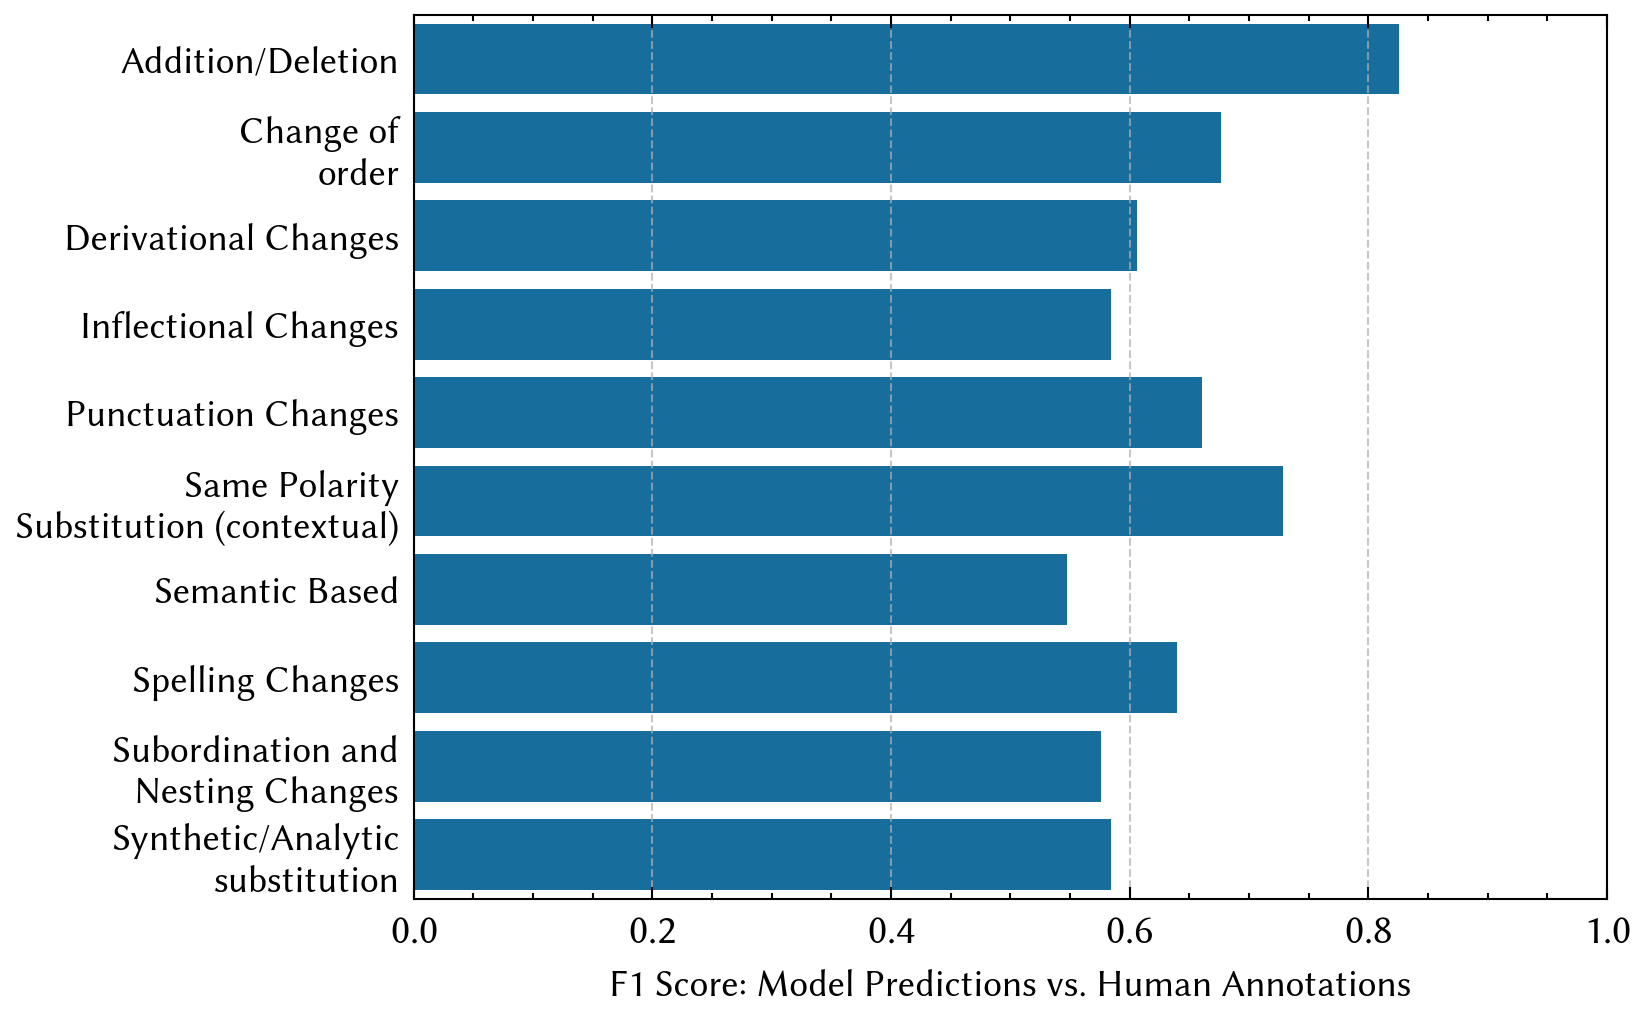

In [40]:
df_results["Paraphrase Type"] = (
    df_results["Paraphrase Type"]
    .map(PARAPHRASE_TYPE_MAPPING)
    .fillna(df_results["Paraphrase Type"])
)

df_results["Paraphrase Type"] = df_results["Paraphrase Type"].apply(
    lambda x: add_line_breaks(x, n=2)
)
df_results = df_results.sort_values(by="Paraphrase Type")

# Create a bar plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300, constrained_layout=True)
plt.style.use(["science", "no-latex"])
sns.set_palette("colorblind")
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]

# Create the bar plot with updated model names
sns.barplot(
    data=df_results,
    y="Paraphrase Type",
    x="F1 Score",
)

# Customize the plot
ax.set_ylabel("")
ax.tick_params(
    axis="y", which="both", left=False, right=False, labelsize=9
)  # Remove tick marks on the y-axis
plt.xlabel("F1 Score: Model Predictions vs. Human Annotations", fontsize=9)
plt.xlim(0, 1)
plt.yticks(fontsize=9)

plt.grid(axis="x", linestyle="--", alpha=0.7)


output_path = os.path.join(output_dir, "new_types.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

### Llama-3.1